In [1]:
using CloudAtlas
using LinearAlgebra
using Base.Threads
using CairoMakie
using DifferentialEquations
using Dates
using LinearAlgebra
using Statistics

In [2]:
struct SolutionFingerprint
    cx::Float64
    cz::Float64
    nm::Float64
end

function get_fingerprint(model, ξ)
    # Extract physical components (assuming ξ = [x..., cx, cz] based on TWModel)
    x, cx, cz = extract_components(ξ, model)
    return SolutionFingerprint(cx, cz, norm(x))
end

function is_distinct(new_fp::SolutionFingerprint, archive::Vector{SolutionFingerprint}; tol=1e-2)
    for fp in archive
        # Check wave speeds and norm
        if isapprox(new_fp.cx, fp.cx, atol=tol) && 
           isapprox(new_fp.cz, fp.cz, atol=tol) && 
           isapprox(new_fp.nm, fp.nm, atol=tol)
            return false # Duplicate found
        end
    end
    return true
end

is_distinct (generic function with 1 method)

In [3]:
"""
    find_fixed_points(model, Re; n_attempts=50, xnorm=0.4)

Searches for unique Traveling Wave solutions for a specific model/discretization.
Returns a vector of solution vectors ξ (state + speeds).
"""
function find_fixed_points(model::TWModel, Re::Real; n_attempts=50, xnorm=0.4, hookparams=CloudAtlas.SearchParams())
    
    m = length(model)
    solutions = Vector{Vector{Float64}}()
    fingerprints = Vector{SolutionFingerprint}()
    
    # Thread-safe locks
    data_lock = ReentrantLock()
    io_lock = ReentrantLock()
    
    println("Starting search for TW solutions (Re=$Re, Attempts=$n_attempts)...")
    
    @threads for i in 1:n_attempts
        print(".")
        # 1. Random Initial Guess
        x_guess = randn(m)
        x_guess = xnorm / norm(x_guess) * x_guess
        
        # Small random wave speeds to break symmetry
        cx_guess = model.keep_cx ? randn() * 0.1 : 0
        cz_guess = model.keep_cz ? randn() * 0.1 : 0
        ξ_guess = [x_guess; cx_guess; cz_guess]

        # 2. Solver Wrappers
        f(ξ) = model.g(ξ, Re)
        Df(ξ) = model.Dg(ξ, Re)
        
        # 3. Solve
        # Note: hookstepsolve must be imported or available
        ξ_star, converged = CloudAtlas.hookstepsolve(f, Df, ξ_guess, hookparams)
        
        # 4. Validation & Storage
        if converged
            # Check basic physical properties (non-trivial solution)
            x_sol = ξ_star[1:m]
            cx = ξ_star[m+1]
            cz = ξ_star[m+2]
            if norm(x_sol) > 1e-2 && (cx > 0 || cz > 0)
                fp = get_fingerprint(model, ξ_star)
                
                lock(data_lock) do
                    if is_distinct(fp, fingerprints)
                        push!(fingerprints, fp)
                        push!(solutions, ξ_star)
                        lock(io_lock) do 
                            println("  \n[Thread $(threadid())] Found unique TW: cx=$(round(fp.cx, digits=4)), |x|=$(round(fp.nm, digits=4))")
                        end
                    end
                end
            end
        end
    end
    
    println("Search complete. Found $(length(solutions)) unique solutions.")
    return solutions
end

find_fixed_points

In [4]:
"""
    generate_turbulent_trajectory(model, Re, tspan; xnorm=0.4)

Generates a time-evolution trajectory starting from a random initial condition.
Returns the ODE solution object.
"""
function generate_turbulent_trajectory(model::TWModel, Re::Real, tspan; xnorm=0.4)
    println("Integrating turbulent trajectory over t=$tspan...")
    
    m = length(model)
    
    # Random initial condition for state x (no wave speeds needed for ODE init x0)
    x0 = randn(m)
    x0 = xnorm / norm(x0) * x0
    
    # We must construct a full ξ vector for integrate_flow, even if we assume cx=cz=0 initially
    # integrate_flow handles the ξ unpacking internally.
    ξ_init = [x0; 0.0; 0.0] 
    
    # Run integration (lab_frame=true effectively simulates DNS)
    sol = integrate_flow(model, TWState(extract_components(ξ_init, model)...), tspan; R=Re, saveat=0.5, lab_frame=true)
    
    return sol
end

generate_turbulent_trajectory

In [5]:
"""
    plot_phase_space_map(model, tw_solutions, traj_sol)

Plots the (I, D) phase portrait.
- Blue dots: Traveling Wave solutions (Fixed Points)
- Black line: Time evolution trajectory
- Dashed line: Laminar/Equilibrium (I=D)
"""
function plot_phase_space_map(model::TWModel, tw_solutions::Vector, traj_sol, D_matrix = nothing)
    
    # 1. Build Dissipation Matrix (expensive, do once)
    if isnothing(D_matrix)
        println("Building dissipation matrix...")
        D_matrix = build_dissipation_matrix(model)
    end
    
    # 2. Calculate I/D for Fixed Points (TWs)
    I_tws = Float64[]
    D_tws = Float64[]
    
    for ξ in tw_solutions
        x, _, _ = extract_components(ξ, model)
        push!(I_tws, power_input(model, x))
        push!(D_tws, dissipation_rate(D_matrix, x))
    end
    
    # 3. Calculate I/D for Trajectory
    println("Calculating metrics for trajectory...")
    I_traj = [CloudAtlas.power_input(model, u) for u in traj_sol.u]
    D_traj = [CloudAtlas.dissipation_rate(D_matrix, u) for u in traj_sol.u]
    
    # 4. Plotting
    fig = Figure(size=(800, 600))
    ax = Axis(fig[1, 1], 
        title="State Space: Power Input vs Dissipation",
        xlabel="Dissipation Rate (D)", 
        ylabel="Power Input (I)"
    )
    
    # Plot Trajectory
    lines!(ax, D_traj, I_traj, color=:black, alpha=0.6, label="Turbulent Trajectory")
    # Mark start and end of trajectory
    scatter!(ax, [D_traj[1]], [I_traj[1]], color=:green, marker=:circle, label="Start")
    scatter!(ax, [D_traj[end]], [I_traj[end]], color=:red, marker=:x, label="End")

    # Plot Fixed Points (TWs)
    scatter!(ax, D_tws, I_tws, color=:blue, markersize=20, label="TW Solutions")
    
    # Plot I=D Line (Equilibrium)
    # Find plot limits to draw the line nicely
    all_D = [D_tws; D_traj]
    all_I = [I_tws; I_traj]
    min_val = min(minimum(all_D), minimum(all_I)) * 0.9
    max_val = max(maximum(all_D), maximum(all_I)) * 1.1
    
    lines!(ax, [min_val, max_val], [min_val, max_val], linestyle=:dash, color=:grey, label="Laminar (I=D)")
    
    axislegend(ax, position=:lt)
    
    return fig
end

plot_phase_space_map

In [6]:
# --- Configuration ---
α, γ = 2π/6.0, 2π/4.0 
Re = 400.0
# Define Discretization
J, K, L = 2, 2, 5
sx, sy, sz, tx, tz = CloudAtlas.halfbox_symmetries()
H = [sz*tx]

# --- 1. Initialize Model ---
model = TWModel(α, γ, J, K, L, H)
model.m

J,K,L,m == 2,2,5,138
(2J+1)(2K+1)(2L+1) + 1 == 276
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = true, keep_cz = false
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 


138

In [7]:
# --- 2. Find Unique Solutions ---
# This runs the fuzzing search in memory
tw_solutions = find_fixed_points(model, Re; n_attempts=1000);
if isempty(tw_solutions)
    println("No TW solutions found. Try increasing attempts or checking parameters.")
end

Starting search for TW solutions (Re=400.0, Attempts=1000)...
.................................................................................  
[Thread 1] Found unique TW: cx=0.1904, |x|=0.0923
...........................................  
[Thread 1] Found unique TW: cx=0.0, |x|=0.0764
..................................................................................................................................................  
[Thread 1] Found unique TW: cx=0.0151, |x|=0.2596
.....  
[Thread 1] Found unique TW: cx=0.0, |x|=0.2495
.......................................................................  
[Thread 1] Found unique TW: cx=0.0323, |x|=0.1491
.............................................................................................................................................................................................................................................................................................................................................

In [8]:
D_matrix = build_dissipation_matrix(model);

Building dissipation matrix...


Integrating turbulent trajectory over t=(0.0, 1000.0)...


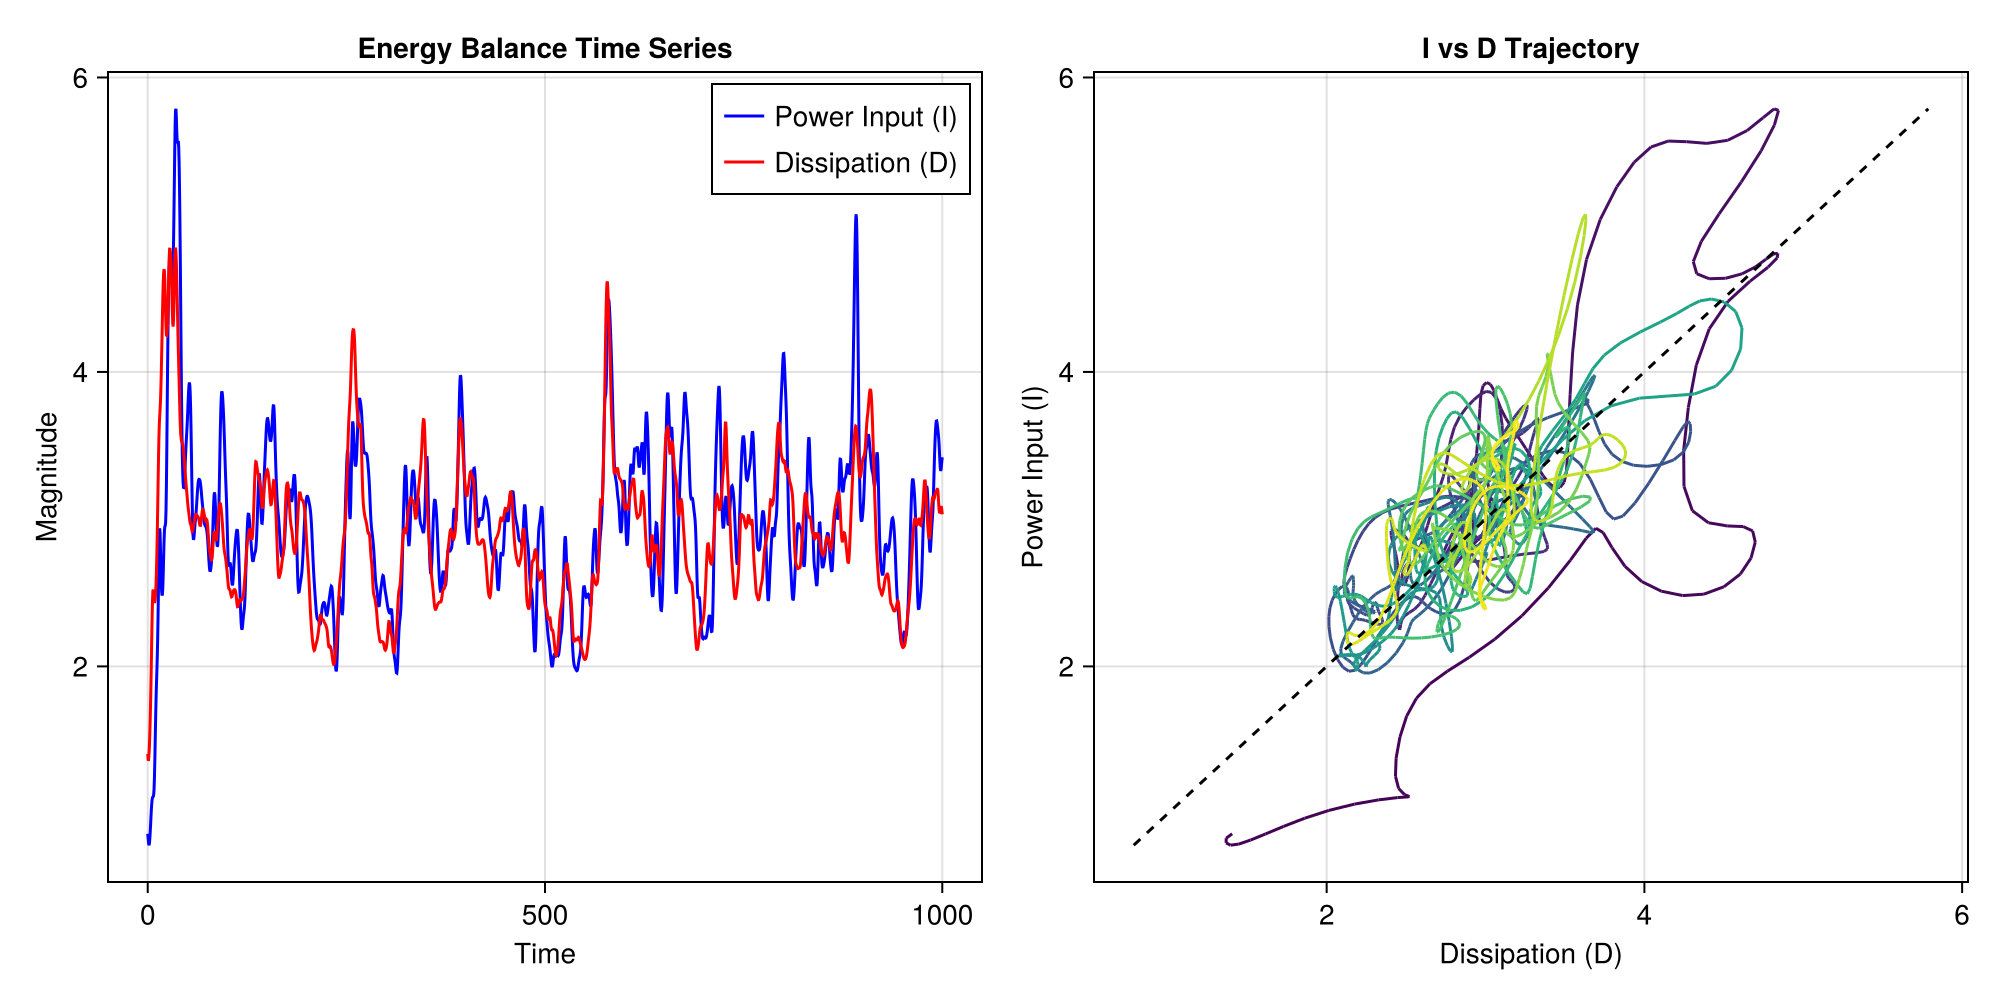

In [9]:
trajectory_sol = generate_turbulent_trajectory(model, Re, (0.0, 1000.0); xnorm=0.1)
plot_id_series(model, trajectory_sol, D_matrix)

Calculating metrics for trajectory...


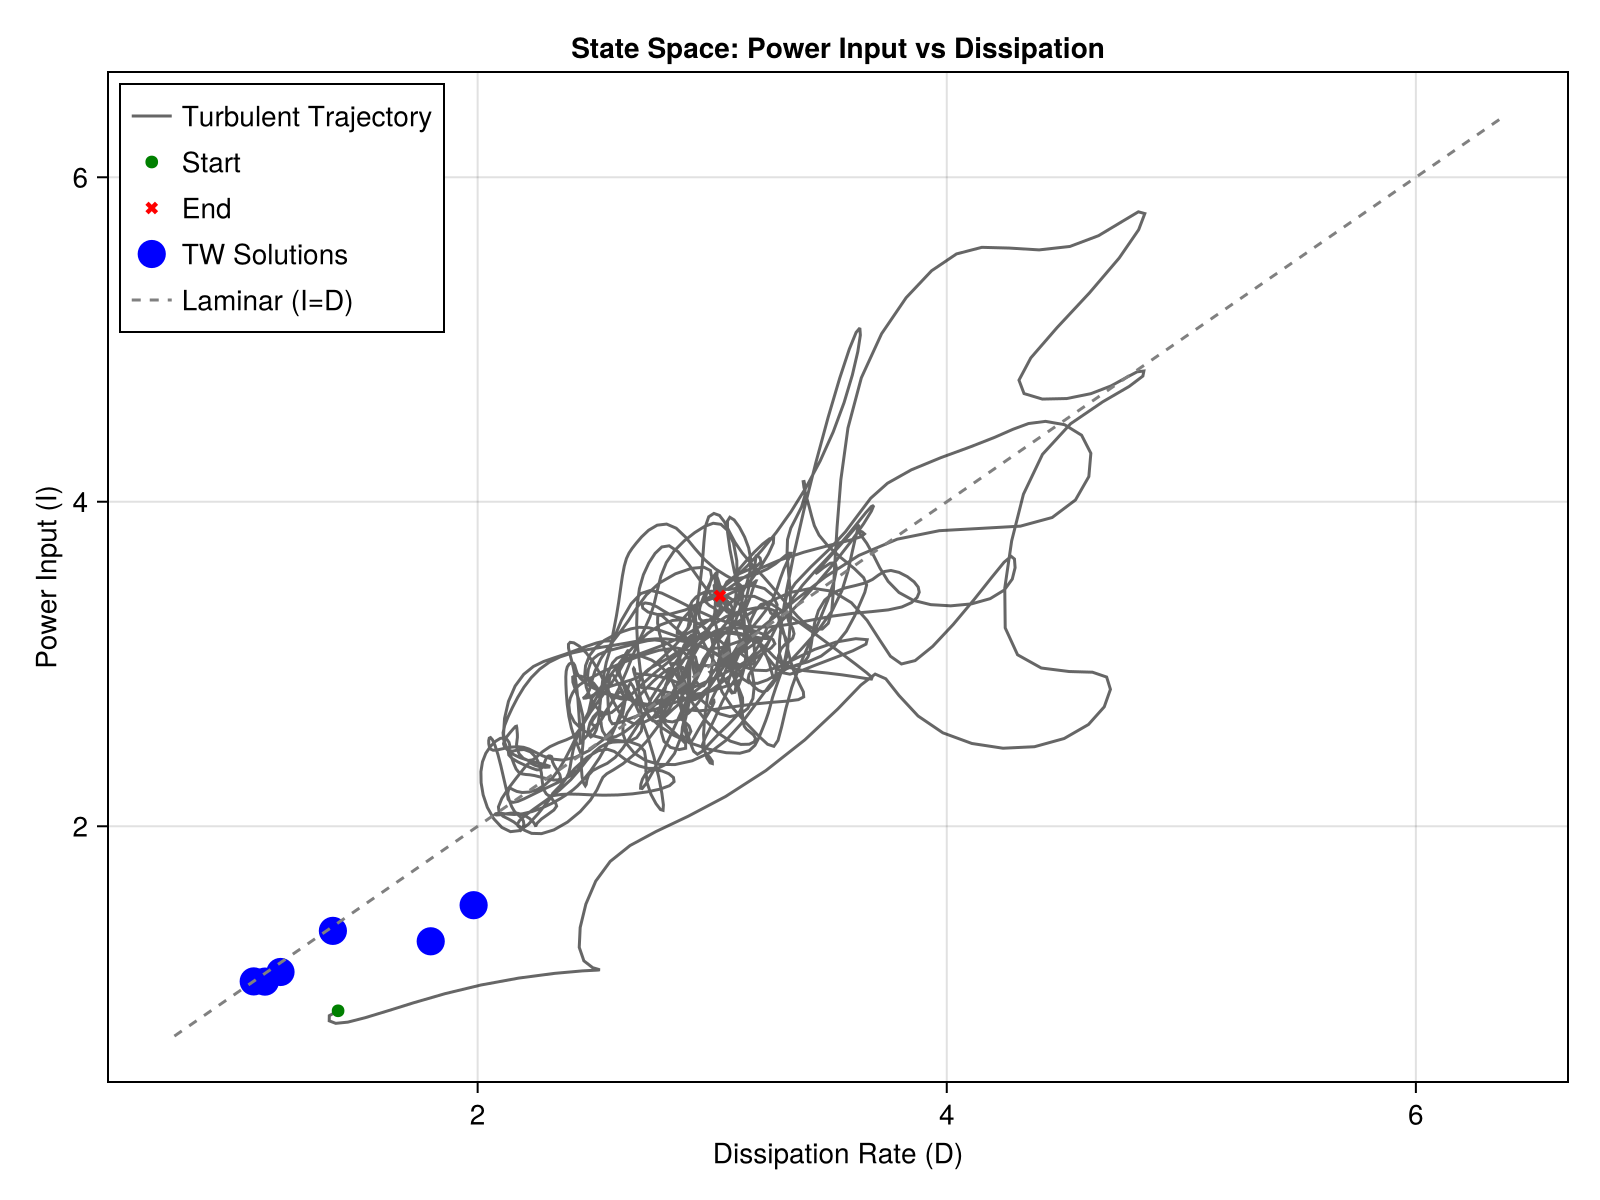

CairoMakie.Screen{IMAGE}


In [10]:
# visualize fixed points nearby
fig = plot_phase_space_map(model, tw_solutions, trajectory_sol, D_matrix)
display(fig)

In [11]:
"""
    find_trajectory_minima(model, sol, D_matrix)

Analyzes a trajectory to find 'Slow Points' in the I-D phase plane.
Returns a list of (time_index, state_vector) tuples to use as Newton guesses.
"""
function find_trajectory_minima(model, sol, D_matrix; window=5)
    # Compute I and D time series
    I_vals = [CloudAtlas.power_input(model, u) for u in sol.u]
    D_vals = [CloudAtlas.dissipation_rate(D_matrix, u) for u in sol.u]
    
    # compute "Phase Velocity" in I-D plane (simple finite difference)
    # velocity ~ sqrt((dI/dt)^2 + (dD/dt)^2)
    vel_id = zeros(length(sol.t))
    
    for i in 2:length(sol.t)
        dt = sol.t[i] - sol.t[i-1]
        dI = (I_vals[i] - I_vals[i-1]) / dt
        dD = (D_vals[i] - D_vals[i-1]) / dt
        vel_id[i] = sqrt(dI^2 + dD^2)
    end
    
    # Find Local Minima (The system is "lingering" near a solution)
    guesses = []
    
    # Simple peak/trough detection
    for i in 1+window : length(vel_id)-window
        # Check if this point is smaller than its neighbors in the window
        local_segment = vel_id[i-window : i+window]
        if vel_id[i] == minimum(local_segment) && vel_id[i] < 0.5 # Threshold helps filter noise
            
            # Construct the guess vector ξ for the Newton solver
            x_guess = sol.u[i]
            
            # small random perturbations help avoid singular jacobians
            cx_guess = model.keep_cx ? randn() * 0.01 : 0
            cz_guess = model.keep_cz ? randn() * 0.01 : 0
            
            ξ_guess = [x_guess; cx_guess; cz_guess]
            
            push!(guesses, (sol.t[i], ξ_guess))
        end
    end
    
    return guesses, I_vals, D_vals, vel_id
end

find_trajectory_minima

In [12]:
"""
    harvest_solutions_from_trajectory(model, Re, sol)

Runs the Newton solver starting from "Slow Points" in the trajectory.
"""
function harvest_solutions_from_trajectory(model::TWModel, Re::Real, sol)
    # 1. Precompute matrix
    D_mat = CloudAtlas.build_dissipation_matrix(model)
    
    # 2. Find promising start points
    candidates, I_vals, D_vals, vel = find_trajectory_minima(model, sol, D_mat)
    
    println("Found $(length(candidates)) candidate snapshots from trajectory.")
    
    solutions = []
    
    # 3. Newton Search
    # Reuse the logic from your fuzzing code
    hookparams = CloudAtlas.SearchParams(Nnewton=40, Nhook=5) # More generous for these guesses
    
    f(ξ) = model.g(ξ, Re)
    Df(ξ) = model.Dg(ξ, Re)

    for (t_val, ξ_guess) in candidates
        print("  Searching from snapshot at t=$t_val... ")
        ξ_star, converged = CloudAtlas.hookstepsolve(f, Df, ξ_guess, hookparams)
        
        if converged
            # Check if it's a trivial solution (Laminar flow has norm ≈ 0 usually, depending on basis)
            # Assuming basis is perturbation, laminar is 0.
            m = length(model)
            x_sol = ξ_star[1:m]
            cx = ξ_star[m+1]
            cz = ξ_star[m+2]
            if norm(x_sol) > 1e-3 && (cx > 0 || cz > 0)
                println("Converged! (Speeds: $(ξ_star[end-1]), $(ξ_star[end]))")
                push!(solutions, ξ_star)
            else
                println("Converged to Laminar (trivial).")
            end
        else
            println("Failed.")
        end
    end
    
    return unique(solutions), I_vals, D_vals, candidates
end

harvest_solutions_from_trajectory

Integrating turbulent trajectory over t=(0.0, 1000.0)...
Building dissipation matrix...
Found 150 candidate snapshots from trajectory.
  Searching from snapshot at t=5.5... Failed.
  Searching from snapshot at t=12.0... Failed.
  Searching from snapshot at t=17.5... Failed.
  Searching from snapshot at t=21.5... Failed.
  Searching from snapshot at t=27.5... Failed.
  Searching from snapshot at t=36.5... Failed.
  Searching from snapshot at t=41.5... Failed.
  Searching from snapshot at t=48.0... Failed.
  Searching from snapshot at t=55.0... Failed.
  Searching from snapshot at t=58.5... Failed.
  Searching from snapshot at t=64.5... Failed.
  Searching from snapshot at t=72.5... Failed.
  Searching from snapshot at t=79.5... Converged! (Speeds: 0.02129155215509392, 0.0)
  Searching from snapshot at t=84.0... Failed.
  Searching from snapshot at t=90.0... Failed.
  Searching from snapshot at t=96.5... Failed.
  Searching from snapshot at t=100.5... Failed.
  Searching from snapshot at

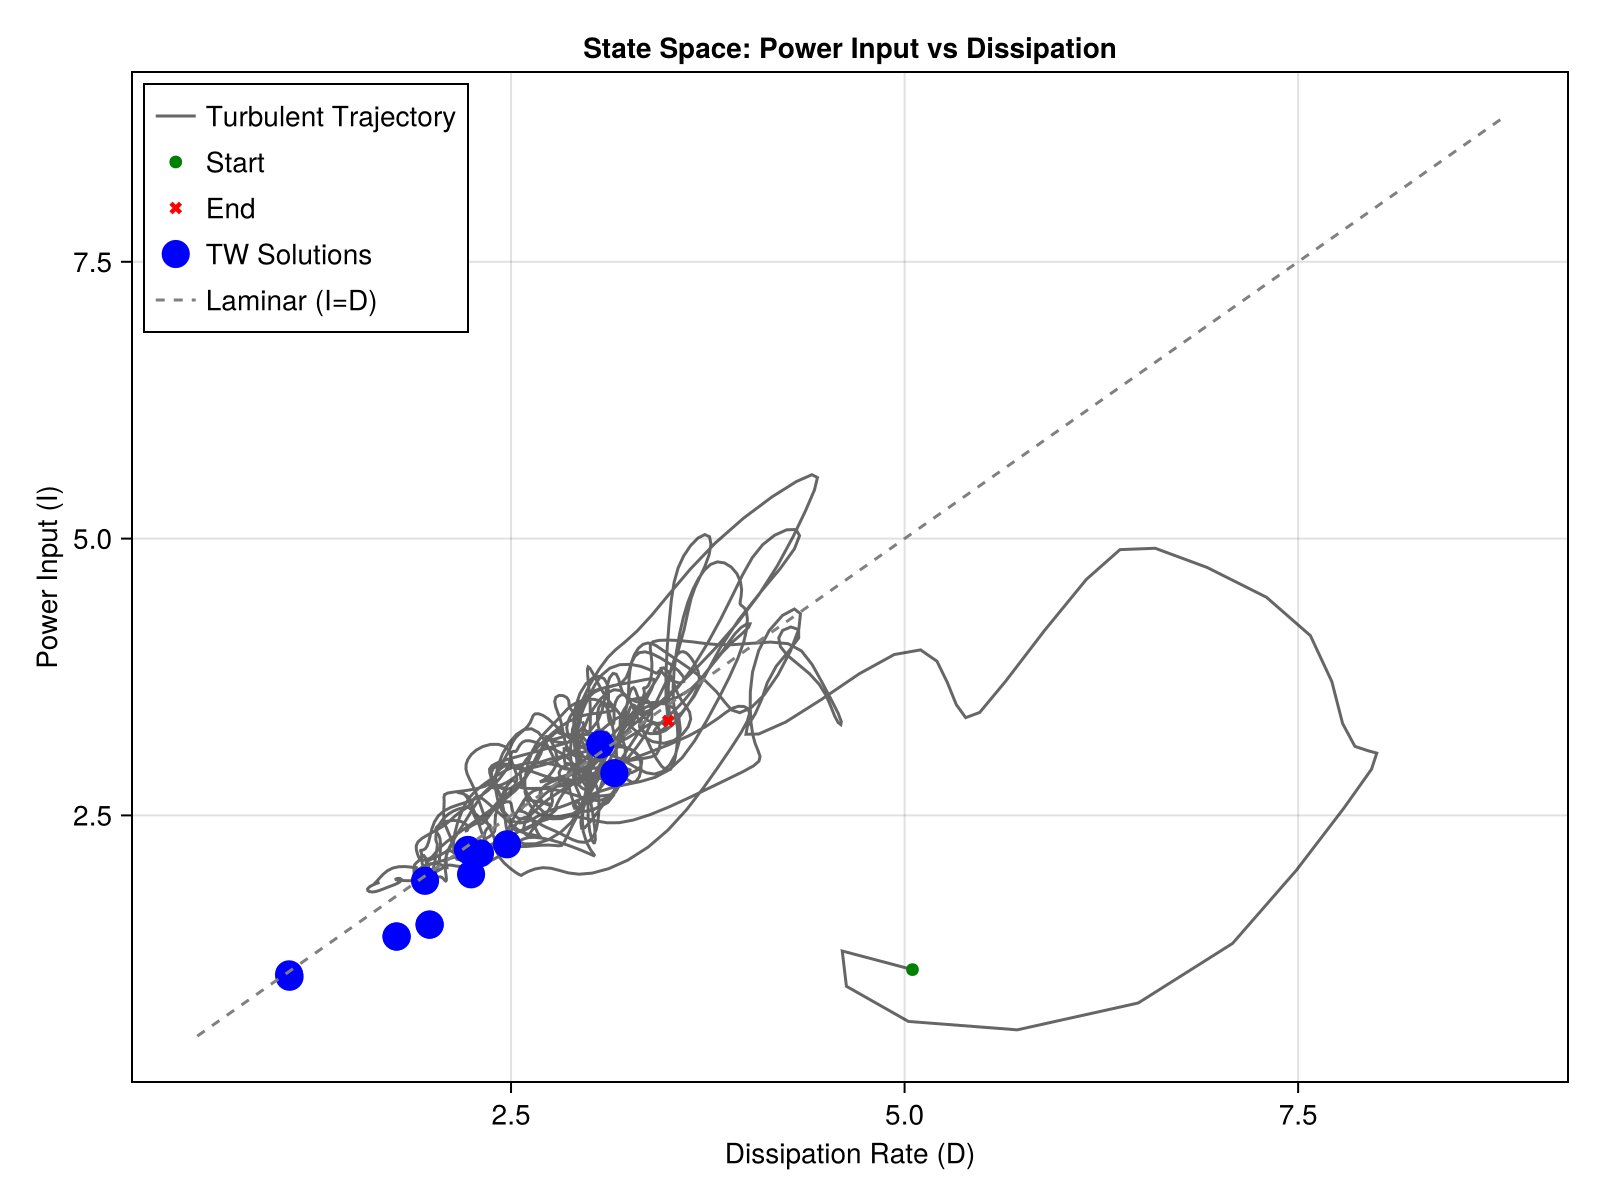

In [13]:
# 1. Generate a long turbulent trajectory (e.g., T=500 or 1000)
# Start from a random kick if you don't have one yet.
long_sol = generate_turbulent_trajectory(model, Re, (0.0, 1000.0); xnorm=0.3)

# 2. Harvest solutions
new_solutions, I, D, candidates = harvest_solutions_from_trajectory(model, Re, long_sol)

# 3. Plot the results
# This will show the trajectory, the points you picked (Slow Points), and the final converged solutions
fig = plot_phase_space_map(model, new_solutions, long_sol)

# (Optional) Overlay the candidate start points to verify logic
# You'll need to manually add scatter points for the candidates' I/D values

In [17]:
using ChannelflowWrapper
reference_field_converted = "reference_field_$(α)_$(γ).nc"
reference_path = "./TW1-2pi1piRe200-40x49x40.nc"
changegrid(reference_path, reference_field_converted; al=α, ga=γ)

Leaving rescale
L2Norm(u0)  == 0.2792590266581449
L2Norm(u1)  == 0.2792590266581447
bcNorm(u0)  == 8.737886593015271e-17
bcNorm(u1)  == 7.538105990587311e-17
divNorm(u0) == 4.746636220033689e-16
divNorm(u1) == 4.887049111322837e-16
L2Norm(u2)  == 0.2792590266581447
divNorm(u2) == 6.695391529748956e-18
bcNorm(u2)  == 7.600850059449384e-17


Process(setenv(`/home/ebenq/.julia/artifacts/6c1f2435997ed534492ee48fcb3cbe0e484642f9/bin/changegrid -al 1.0471975511965976 -ga 1.5707963267948966 ./TW1-2pi1piRe200-40x49x40.nc reference_field_1.0471975511965976_1.5707963267948966.nc`,["PATH=/home/ebenq/.julia/artifacts/7f39a18d94f87b5135df6731a327b61b8c463af6/bin:/home/ebenq/.julia/artifacts/235aa219585823fcc7f270b3d0efdaec60267f1b/bin:/home/ebenq/.julia/artifacts/4a89e14d2f652ad45bcc093d040c97fbcc1a3669/bin:/home/ebenq/.julia/artifacts/fddb41451df711c595969c8571404433623c75f6/bin:/home/ebenq/.julia/artifacts/117d9048128625bb3418b0b4cca48739c5d28740/bin:/home/ebenq/.julia/artifacts/2117b531439d782e1cb0ebffcc4dcf11d274cc39/bin:/home/ebenq/.julia/artifacts/8c83eff7b29912d7bd1e42aef04f7822159494c3/bin:/home/ebenq/.julia/artifacts/4db1e58d71ac6bbb35ecc832033264c630d5d3b3/bin:/home/ebenq/.julia/artifacts/45a076ac2b0b5e528159c96142254106709ec982/bin:/home/ebenq/.julia/artifacts/574d3c478e920d12d391926b5a8da6a2bf293c8a/bin:/home/ebenq/.julia

In [23]:
base_dir="cont_results"
m = model.m
T = 10.0
symm_file = "./sztx.asc"

for ξ_star in new_solutions
    timestamp = Dates.format(now(), "MM-DD-HHMMSS")
    sol_dir = joinpath(base_dir, "sol_$(J)_$(K)_$(L)_$(timestamp)")
    mkpath(sol_dir)
    guess_path = joinpath(sol_dir, "u_guess.nc")
    sigma_file = joinpath(sol_dir, "sigma.asc")
    
    coeff2field(ξ_star[1:m], model.ijkl, reference_field_converted, guess_path)
    save_sigma(model, ξ_star[end - 1], ξ_star[end], T, sigma_file)
    
    try
        findsoln(guess_path;
            R = Re, eqb = true, xrel = model.keep_cx, zrel = model.keep_cz,
            symms = abspath(symm_file), sigma = sigma_file, od = sol_dir, T = T
        )
    catch e
        println("findsoln failed: $e")
    end
end

alpha, gamma == 1.047197551196598, 1.570796326794897
Nx, Ny, Nz == 40, 49, 40
Reading ijkl indices of basis set from file
reading N == 138 ijkl indices
ijkl[0] == 1 0 0 0
L == max l == 5
Constructing Legendre polynomials
Assigning Polynomial, size = 1 
Assigning Polynomial, size = 0 1 
Assigning Polynomial, size = -0.5 0 1.5 
Assigning Polynomial, size = 0 -1.5 0 2.5 
Assigning Polynomial, size = 0.375 0 -3.75 0 4.375 
Assigning Polynomial, size = 0 1.875 0 -8.75 0 7.875 
Constructing S, and Sprime polynomials
Assigning Polynomial, size = 0 1 0 -0.3333333333333333 
Assigning Polynomial, size = 1 0 -2 0 1 
Assigning Polynomial, size = 0 1 0 -2 0 1 
Assigning Polynomial, size = -0.5 0 2.5 0 -3.5 0 1.5 
Assigning Polynomial, size = 0 -1.5 0 5.5 0 -6.5 0 2.5 
Assigning Polynomial, size = 0.375 0 -4.5 0 12.25 0 -12.5 0 4.375 
Assigning Polynomial, size = 1 0 -1 
Assigning Polynomial, size = 0 -4 0 4 
Assigning Polynomial, size = 1 0 -6 0 5 
Assigning Polynomial, size = 0 5 0 -14 0 9 
Assign

57503 unknowns
Computing G(x)
f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.348056
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.0106246
   previous gx == 0.0106246
   current  gx == 0.0106246
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 5.64408e-05
   previous rx == 5.64408e-05
   current  rx == 5.64408e-05
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.859869
Newt,GMRES == 0,1, f^T: ....10 res == 0.859846
Newt,GMRES == 0,2, f^T: ....10 res == 0.832838
Newt,GMRES == 0,3, f^T: ....10 res == 0.826623
Newt,GMRES == 0,4, f^T: ....10 res == 0.825272
Newt,GMRES == 0,5, f^T: ....10 res == 0.821265
Newt,GMRES == 0,6, f^T: ....10 res == 0.810158
Newt,GMRES == 0,7, f^T: ....10 res == 0.789404
Newt,GMRES == 0,8, f^T: ....10 res == 0.711635
Newt,GMRES == 0,9, f^T: ....10 res == 0.711629
Newt,GMRES == 0,10, f^T: ....1

L2Dist(u,uout) == 0.263911592441961
L2Dist(u,uout)/L2Norm(u) == 0.9450422985432403
nu==0.0025, Vsuck==0, rotation==0, theta==0, dPdx==0, dPdz==0, Ubulk==0, Wbulk==0, uwall==1, uupper==1, ulower==-1, wupper==0, wlower==-0, t0==0, dT==1, dt==0.03125, variabledt==1, dtmin==0.001, dtmax==0.2, CFLmin==0.4, CFLmax==0.6, LaminarBase, PressureGradient, SBDF3, SMRK2, Rotational, DealiasXZ, zero_bodyforce, TauCorrection, Silent
57503 unknowns
Computing G(x)
f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.194535
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.00645749
   previous gx == 0.00645749
   current  gx == 0.00645749
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 2.08496e-05
   previous rx == 2.08496e-05
   current  rx == 2.08496e-05
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.973071
Newt,GMRES == 0,1, f^T: ....

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.0499231
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.00222998
   previous gx == 0.00222998
   current  gx == 0.00222998
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 2.48641e-06
   previous rx == 2.48641e-06
   current  rx == 2.48641e-06
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.755865
Newt,GMRES == 0,1, f^T: ....10 res == 0.569396
Newt,GMRES == 0,2, f^T: ....10 res == 0.56157
Newt,GMRES == 0,3, f^T: ....10 res == 0.560889
Newt,GMRES == 0,4, f^T: ....10 res == 0.560213
Newt,GMRES == 0,5, f^T: ....10 res == 0.552149
Newt,GMRES == 0,6, f^T: ....10 res == 0.470304
Newt,GMRES == 0,7, f^T: ....10 res == 0.461945
Newt,GMRES == 0,8, f^T: ....10 res == 0.460977
Newt,GMRES == 0,9, f^T: ....10 res == 0.440742
Newt,GMRES == 0,10, f^T: ....10 res == 0.414443
Newt,GMRE

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.0473014
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.00129283
   previous gx == 0.00129283
   current  gx == 0.00129283
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 8.35705e-07
   previous rx == 8.35705e-07
   current  rx == 8.35705e-07
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.779005
Newt,GMRES == 0,1, f^T: ....10 res == 0.768172
Newt,GMRES == 0,2, f^T: ....10 res == 0.607816
Newt,GMRES == 0,3, f^T: ....10 res == 0.363233
Newt,GMRES == 0,4, f^T: ....10 res == 0.149034
Newt,GMRES == 0,5, f^T: ....10 res == 0.0792494
Newt,GMRES == 0,6, f^T: ....10 res == 0.0388107
Newt,GMRES == 0,7, f^T: ....10 res == 0.013488
Newt,GMRES == 0,8, f^T: ....10 res == 0.00319183
Newt,GMRES == 0,9, f^T: ....10 res == 0.000712764
GMRES converged. Breaking.
----------------------

Excessive output truncated after 524338 bytes.